In [ ]:
# Install required libraries
!pip install transformers datasets torch torchvision timm --quiet



In [ ]:
# Imports
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import AutoFeatureExtractor, SwinForImageClassification
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class RiceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.items = []
        self.class_names = ["Karacadag","Arborio","Basmati","Ipsala","Jasmine"]
        self.class2idx = {c:i for i,c in enumerate(self.class_names)}

        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            for img in os.listdir(cls_path):
                self.items.append((os.path.join(cls_path, img), self.class2idx[cls]))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
image_size = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


In [ ]:
train_dataset = RiceDataset("/content/drive/MyDrive/rice_swimtranfomer/train", transform=train_transform)
test_dataset  = RiceDataset("/content/drive/MyDrive/rice_swimtranfomer/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [ ]:
from torch.cuda.amp import autocast, GradScaler
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=5,
    ignore_mismatched_sizes=True
)

# Freeze backbone
for param in model.swin.parameters():
    param.requires_grad = False

# Only train the classifier head
for param in model.classifier.parameters():
    param.requires_grad = True


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()

scaler = GradScaler()  # For mixed precision


/tmp/ipython-input-1145762018.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision


In [ ]:
epochs = 5  # only fine-tuning head, 3-5 epochs is enough

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():  # mixed precision
            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


/tmp/ipython-input-1073012789.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # mixed precision


Epoch 1/5, Loss: 0.4370
Epoch 2/5, Loss: 0.1198
Epoch 3/5, Loss: 0.0735
Epoch 4/5, Loss: 0.0545
Epoch 5/5, Loss: 0.0440


In [11]:
model.eval()
preds, truths = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(pixel_values=images).logits
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        preds.extend(pred)
        truths.extend(labels.numpy())


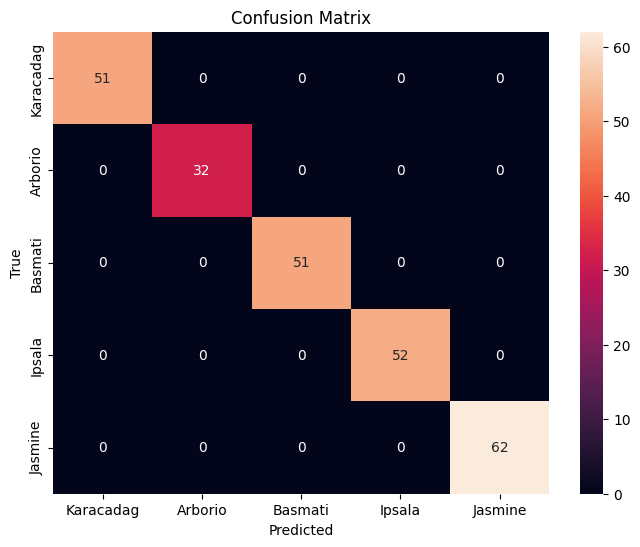

In [12]:
cm = confusion_matrix(truths, preds)
plt.figure(figsize=(8,6))
sn.heatmap(cm, annot=True, fmt="d",
           xticklabels=train_dataset.class_names,
           yticklabels=train_dataset.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


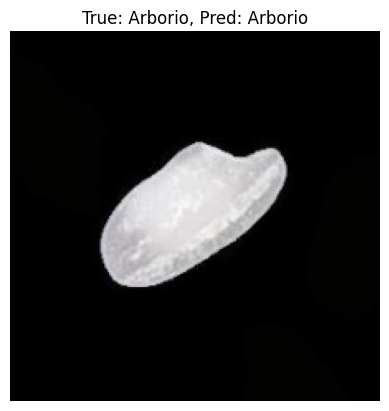

In [13]:
def display_random_image(dataset, predictions):
    import random
    idx = random.randint(0, len(dataset)-1)
    img, label = dataset[idx]
    img_show = img.permute(1,2,0).numpy()  # CHW -> HWC
    img_show = img_show * np.array(std) + np.array(mean)  # denormalize
    img_show = np.clip(img_show, 0, 1)

    plt.imshow(img_show)
    plt.title(f"True: {dataset.class_names[label]}, Pred: {dataset.class_names[predictions[idx]]}")
    plt.axis('off')
    plt.show()

display_random_image(test_dataset, preds)


In [14]:
# Save the full model
torch.save(model.state_dict(), "swin_rice_model.pth")
print("Model saved successfully!")


Model saved successfully!


In [15]:
# Recreate model architecture
model_loaded = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=5,
    ignore_mismatched_sizes=True
)

# Load saved weights
model_loaded.load_state_dict(torch.load("swin_rice_model.pth", map_location=device))
model_loaded.to(device)
model_loaded.eval()  # important for inference
print("Model loaded successfully!")


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded successfully!


In [ ]:
import os
from flask import Flask, render_template, request
from PIL import Image
import torch
from torchvision import transforms
from transformers import SwinForImageClassification

# ------------------ Flask Setup ------------------
app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = 'uploads'
os.makedirs(app.config['UPLOAD_FOLDER'], exist_ok=True)

# ------------------ Device ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ Class Names ------------------
class_names = ["Karacadag","Arborio","Basmati","Ipsala","Jasmine"]

# ------------------ Load Model ------------------
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=5,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load("/content/swin_rice_model.pth", map_location=device))
model.to(device)
model.eval()

# ------------------ Preprocessing ------------------
def preprocess_image(img_path):
    image = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    image = transform(image).unsqueeze(0)  # Add batch dimension
    return image.to(device)

# ------------------ Routes ------------------
@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    if request.method == "POST":
        if "file" not in request.files:
            return render_template("index.html", prediction="No file uploaded")
        file = request.files["file"]
        if file.filename == "":
            return render_template("index.html", prediction="No file selected")
        if file:
            file_path = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
            file.save(file_path)

            # Preprocess and predict
            image_tensor = preprocess_image(file_path)
            with torch.no_grad():
                logits = model(pixel_values=image_tensor).logits
                pred_idx = torch.argmax(logits, dim=1).item()
                prediction = class_names[pred_idx]

    return render_template("index.html", prediction=prediction)

# ------------------ Run ------------------
if __name__ == "__main__":
    app.run(debug=True)


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
